In [18]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Dataset
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import numpy as np

from google.colab import files, drive

In [19]:
# Hyperparameters
layers = [3, 64, 64, 64, 1]
lr = 1e-3
batch_size = 32
epochs = 10

In [20]:
def sdf_box(p, top_left, bottom_right):
    """
    SDF for an axis-aligned box.

    Parameters
    ----------
    p : (N, 2) array of points to evaluate
    top_left : (2,) array-like — coordinates of the top-left corner of the box
    bottom_right : (2,) array-like — coordinates of the bottom-right corner of the box
    """
    top_left = np.array(top_left)
    bottom_right = np.array(bottom_right)
    
    center = (top_left + bottom_right) / 2
    half_size = np.abs(bottom_right - top_left) / 2  # Use absolute value

    d = np.abs(p - center) - half_size
    outside_dist = np.linalg.norm(np.maximum(d, 0), axis=-1)
    inside_dist = -np.minimum(np.abs(d[..., 0]), np.abs(d[..., 1]))

    inside = np.all(d <= 0, axis=-1)
    return np.where(inside, inside_dist, outside_dist)


def sdf_circle(p, center, radius):
    """
    SDF for a circle.

    Parameters
    ----------
    p : (N, 2) array of points to evaluate
    center : (2,) array-like — coordinates of the circle center
    radius : float — radius of the circle
    """
    center = np.array(center)
    return np.linalg.norm(p - center, axis=-1) - radius


def sdf_union(p, sdf1, sdf2):
    """
    SDF of the union of two SDFs.
    Parameters
    ----------
    p : (N, 2) array of points to evaluate
    sdf1, sdf2 : functions that take (N, 2) array and return (N,) array of signed distances
    """
    return np.minimum(sdf1(p), sdf2(p))

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Plate parameters
size = 2.0
t_max = 5.0
alpha = 0.01
q = 0.5

rect_sdf = lambda p: sdf_box(p, top_left=[-0.75, 0.75], bottom_right=[-0.25, -0.75])
circ_sdf = lambda p: sdf_circle(p, center=[0.0, 0.375], radius=0.5)
SDF = lambda p: sdf_union(p, rect_sdf, circ_sdf)

Using device: cuda


In [22]:
!wget -O SDF_CF.csv https://raw.githubusercontent.com/brcktn/Inverse-Heat-PINN/main/training_data/SDF_CF.csv

class CSVDataset(Dataset):
    def __init__(self, csv_file):
        data = pd.read_csv(csv_file).values.astype(np.float32)
        self.X = torch.from_numpy(data[:, 1:4])  # coords (x, y, t)
        self.y = torch.from_numpy(data[:, 4:])   # temperature

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = CSVDataset('SDF_CF.csv')
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# next(iter(dataloader))

--2026-04-18 01:08:22--  https://raw.githubusercontent.com/brcktn/Inverse-Heat-PINN/main/training_data/SDF_CF.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 630256 (615K) [text/plain]
Saving to: ‘SDF_CF.csv’

SDF_CF.csv          100%[===================>] 615.48K  --.-KB/s    in 0.02s   

2026-04-18 01:08:23 (36.5 MB/s) - ‘SDF_CF.csv’ saved [630256/630256]



In [23]:
class HeatPINN(nn.Module):
    def __init__(self, layers):
        """
        Parameters
        ----------
        layers : list of int
            A list of integers specifying the number of neurons in each layer
        """
        super(HeatPINN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
            if i < len(layers) - 2:
                self.layers.append(nn.SiLU())

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [24]:
def sample_points(num_points, t_max, SDF):
    """
    Sample points in space and time within the domain defined by the SDF.
    
    Parameters
    ----------
    num_points : int
        Total number of points to sample
    t_max : float
        Maximum time to sample
    SDF : function
        A function that takes (N, 2) coordinates and returns their SDF values
    """
    points = []
    while len(points) < num_points:
        x = np.random.uniform(-size/2, size/2)
        y = np.random.uniform(-size/2, size/2)
        t = np.random.uniform(0, t_max)
        if SDF(np.array([[x, y]])) < 0:  # Inside the domain
            points.append([x, y, t])
    return torch.tensor(points, dtype=torch.float32)


def sample_boundary_points(num_points, t_max, SDF, eps=1e-4, steps=10):
    """
    Sample points precisely on the boundary of the domain defined by the SDF
    using gradient descent projection. Returns points and their unit normals.
    
    Parameters
    ----------
    num_points : int
        Total number of points to sample
    t_max : float
        Maximum time to sample
    SDF : function
        A function that takes (N, 2) coordinates and returns their SDF values
        
    Returns
    -------
    points : torch.Tensor
        (N, 3) tensor of (x, y, t) coordinates on the boundary
    normals : torch.Tensor
        (N, 2) tensor of (nx, ny) unit normal vectors at those points
    """
    # Start with random points in domain for spatial coords (x,y) and time (t)
    pts_xy = np.random.uniform(-size/2, size/2, (num_points * 10, 2))
    pts_t = np.random.uniform(0, t_max, (num_points * 10, 1))
    
    # Project onto surface via numerical gradient descent on the SDF
    # (Since the SDF is currently implemented with NumPy, we use numerical gradients)
    dx = 1e-5
    for _ in range(steps):
        f = SDF(pts_xy)
        
        grad_x = (SDF(pts_xy + np.array([dx, 0])) - SDF(pts_xy - np.array([dx, 0]))) / (2 * dx)
        grad_y = (SDF(pts_xy + np.array([0, dx])) - SDF(pts_xy - np.array([0, dx]))) / (2 * dx)
        grad = np.stack([grad_x, grad_y], axis=-1)
        
        grad_norm = np.linalg.norm(grad, axis=-1, keepdims=True)
        pts_xy -= np.expand_dims(f, -1) * grad / (grad_norm + 1e-8)
    
    # Keep points that converged precisely to the surface
    f = SDF(pts_xy)
    on_surface = np.abs(f) < eps
    
    pts_xy_surface = pts_xy[on_surface]
    pts_t_surface = pts_t[on_surface]
    
    # Compute normals for the converged points
    grad_x = (SDF(pts_xy_surface + np.array([dx, 0])) - SDF(pts_xy_surface - np.array([dx, 0]))) / (2 * dx)
    grad_y = (SDF(pts_xy_surface + np.array([0, dx])) - SDF(pts_xy_surface - np.array([0, dx]))) / (2 * dx)
    normals = np.stack([grad_x, grad_y], axis=-1)
    normals = normals / (np.linalg.norm(normals, axis=-1, keepdims=True) + 1e-8)
    
    points = np.concatenate([pts_xy_surface, pts_t_surface], axis=-1)
    
    return torch.tensor(points[:num_points], dtype=torch.float32), torch.tensor(normals[:num_points], dtype=torch.float32)

In [25]:
def data_loss(model, points, temperatures):
    """
    MSE loss between model predictions and observed temperatures at given points.

    Parameters
    ----------
    model : nn.Module
        The PINN model
    points : (N, 3) tensor
        The (x, y, t) coordinates of the observed data points
    temperatures : (N, 1) tensor
        The observed temperatures at the given points

    Returns
    -------
    torch.Tensor
        The computed MSE loss
    """
    x_batch = points.to(device)
    y_batch = temperatures.to(device)
    pred = model(x_batch)
    return nn.MSELoss()(pred, y_batch)


def physics_loss(model, points, alpha):
    """
    Physics loss enforcing the heat equation at given points.

    Parameters
    ----------
    model : nn.Module
        The PINN model
    points : (N, 3) tensor
        The (x, y, t) coordinates of the collocation points
    alpha : float
        Thermal diffusivity constant

    Returns
    -------
    torch.Tensor
        The computed physics loss
    """
    points = points.to(device).requires_grad_(True)
    pred = model(points)
    
    # Gradients
    u_t = torch.autograd.grad(pred, points, grad_outputs=torch.ones_like(pred), create_graph=True)[0][:, 2:3]
    u_x = torch.autograd.grad(pred, points, grad_outputs=torch.ones_like(pred), create_graph=True)[0][:, 0:1]
    u_y = torch.autograd.grad(pred, points, grad_outputs=torch.ones_like(pred), create_graph=True)[0][:, 1:2]
    
    u_xx = torch.autograd.grad(u_x, points, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = torch.autograd.grad(u_y, points, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:, 1:2]

    residual = u_t - alpha * (u_xx + u_yy)
    return torch.mean(residual**2)


def boundary_loss(model, points, normals, q, alpha):
    """
    Loss enforcing constant flux boundary conditions at given points.

    Parameters
    ----------
    model : nn.Module
        The PINN model
    points : (N, 3) tensor
        The (x, y, t) coordinates of the boundary points
    normals : (N, 2) tensor
        The unit normal vectors at the boundary points
    q : float
        The heat flux at the boundary (Neumann condition)
    alpha : float
        Thermal diffusivity constant

    Returns
    -------
    torch.Tensor
        The computed boundary loss
    """
    # CRITICAL: points must have requires_grad_(True) to compute derivatives
    points = points.to(device).requires_grad_(True)
    normals = normals.to(device)
    q_tensor = torch.tensor(q, dtype=torch.float32).to(device)

    pred = model(points)
    u_x = torch.autograd.grad(pred, points, grad_outputs=torch.ones_like(pred), create_graph=True)[0][:, 0:1]
    u_y = torch.autograd.grad(pred, points, grad_outputs=torch.ones_like(pred), create_graph=True)[0][:, 1:2]
    flux = u_x * normals[:, 0:1] + u_y * normals[:, 1:2]
    
    return torch.mean((flux + q_tensor / alpha)**2)

In [26]:
def train(model, dataloader, optimizer):
    import time
    model.train()
    for epoch in range(epochs):
        epoch_start = time.time()
        total_loss = 0.0
        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_bound_loss = 0.0

        for points, temperatures in dataloader:
            optimizer.zero_grad()
            
            # Sample collocation points for physics and boundary loss
            physics_points = sample_points(batch_size, t_max, SDF)
            # Unpack both points and normals
            boundary_points, normals = sample_boundary_points(batch_size, t_max, SDF)

            # Compute loss
            d_loss = data_loss(model, points, temperatures)
            p_loss = physics_loss(model, physics_points, alpha)
            # Pass all required arguments to boundary_loss
            b_loss = boundary_loss(model, boundary_points, normals, q, alpha)
            loss = d_loss + p_loss + b_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_data_loss += d_loss.item()
            total_phys_loss += p_loss.item()
            total_bound_loss += b_loss.item()

        epoch_time = time.time() - epoch_start
        avg_loss = total_loss / len(dataloader)
        avg_data_loss = total_data_loss / len(dataloader)
        avg_phys_loss = total_phys_loss / len(dataloader)
        avg_bound_loss = total_bound_loss / len(dataloader)

        print(f"Epoch {epoch+1:03d}/{epochs}, Loss: {avg_loss:.6f}, Data Loss: {avg_data_loss:.6f}, Phys Loss: {avg_phys_loss:.6f}, Bound Loss: {avg_bound_loss:.6f}, Time: {epoch_time:.2f}s")

In [27]:
model = HeatPINN(layers).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train(model, dataloader, optimizer)

Epoch 001/10, Loss: 1266.808175, Data Loss: 380.513361, Phys Loss: 12.658622, Bound Loss: 873.636195, Time: 14.26s
Epoch 002/10, Loss: 138.481529, Data Loss: 68.125458, Phys Loss: 3.837359, Bound Loss: 66.518711, Time: 15.00s
Epoch 003/10, Loss: 61.400494, Data Loss: 24.143810, Phys Loss: 6.737532, Bound Loss: 30.519153, Time: 14.35s
Epoch 004/10, Loss: 37.998346, Data Loss: 12.433405, Phys Loss: 7.365250, Bound Loss: 18.199691, Time: 14.54s
Epoch 005/10, Loss: 29.198992, Data Loss: 8.447641, Phys Loss: 7.139946, Bound Loss: 13.611405, Time: 14.42s
Epoch 006/10, Loss: 23.001918, Data Loss: 5.615350, Phys Loss: 6.679265, Bound Loss: 10.707303, Time: 14.34s
Epoch 007/10, Loss: 20.229056, Data Loss: 3.948506, Phys Loss: 5.963318, Bound Loss: 10.317232, Time: 14.41s
Epoch 008/10, Loss: 17.154020, Data Loss: 2.946438, Phys Loss: 5.369777, Bound Loss: 8.837805, Time: 14.87s
Epoch 009/10, Loss: 16.265223, Data Loss: 2.474160, Phys Loss: 4.842681, Bound Loss: 8.948382, Time: 14.27s
Epoch 010/1

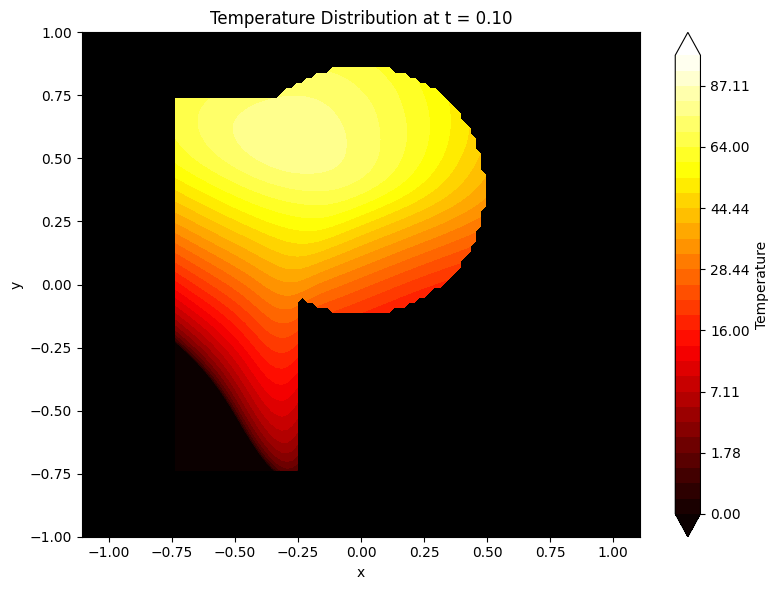

In [33]:
import matplotlib.colors as colors

def plot_heatmap(model, t, size=2.5, resolution=100):
    """
    Plot a heatmap of the temperature distribution at a given time.
    
    Parameters
    ----------
    model : nn.Module
        The trained PINN model.
    t : float
        The time at which to plot the temperature distribution.
    size : float
        The size of the spatial domain (length of the plate).
    resolution : int
        The number of points in each spatial dimension for the grid.
    """
    model.eval()
    
    # Create a grid of (x, y) points
    x = torch.linspace(-size/2, size/2, resolution)
    y = torch.linspace(-size/2, size/2, resolution)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    
    # Flatten and create input tensor with constant time
    x_flat = X.flatten().unsqueeze(1)
    y_flat = Y.flatten().unsqueeze(1)
    t_tensor = torch.full_like(x_flat, t)
    
    points = torch.cat([x_flat, y_flat, t_tensor], dim=1).to(device)
    
    # Get predictions
    with torch.no_grad():
        u = model(points)
    
    # Reshape to grid
    U = u.reshape(resolution, resolution).cpu().numpy()
    
    # Mask values outside the SDF geometry
    coords = np.stack([X.flatten().numpy(), Y.flatten().numpy()], axis=-1)
    sdf_vals = SDF(coords).reshape(resolution, resolution)
    U[sdf_vals > 0] = np.nan  # Set points outside the boundary to NaN
    
    # Fix the scale to always range from 0 to 100
    vmin = 0.0
    vmax = 100.0
    
    # Configure colormap to render NaN values (outside boundary) as black
    cmap_obj = plt.get_cmap('hot').copy()
    cmap_obj.set_bad(color='black')
    
    # Plot
    plt.figure(figsize=(8, 6), dpi=100)
    # Set axis background to black so the transparent NaN contours appear black
    plt.gca().set_facecolor('black')
    
    # Use non-linear levels packed closer together at the bottom to increase low-temperature visibility
    levels = (np.linspace(0, 1, 31) ** 2) * vmax
    
    # We apply a PowerNorm using gamma < 1 to dynamically spread the colors over the lower values
    norm = colors.PowerNorm(gamma=0.5, vmin=vmin, vmax=vmax)
    
    plt.contourf(X.numpy(), Y.numpy(), U, levels=levels, cmap=cmap_obj, norm=norm, extend='both')
    plt.colorbar(label='Temperature')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Temperature Distribution at t = {t:.2f}')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    model.train()

plot_heatmap(model, t=0.1, size=size, resolution=100)

In [29]:
# drive.mount('/content/drive')
# timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
# torch.save(model.state_dict(), f'/content/drive/My Drive/Heat PINN weights/heat_pinn_model_sdf_T_{timestamp}.pth')